In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"..\Dataset\dataset_module_one_DM2.csv")
df.shape

(8384, 37)

In [3]:
col_bin = [col for col in df.columns if df[col].nunique() == 2]
print(col_bin)

['Basic_Demos-Sex', 'FGC-FGC_CU_Zone', 'FGC-FGC_PU_Zone', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR_Zone', 'FGC-FGC_TL_Zone']


In [4]:
for col in col_bin:
    print(df[col].value_counts())

Basic_Demos-Sex
0    5003
1    3381
Name: count, dtype: int64
FGC-FGC_CU_Zone
0.0    5302
1.0    3082
Name: count, dtype: int64
FGC-FGC_PU_Zone
0.0    6720
1.0    1664
Name: count, dtype: int64
FGC-FGC_SRL_Zone
1.0    6277
0.0    2107
Name: count, dtype: int64
FGC-FGC_SRR_Zone
1.0    6052
0.0    2332
Name: count, dtype: int64
FGC-FGC_TL_Zone
1.0    7189
0.0    1195
Name: count, dtype: int64


In [5]:
# 1. Separate the two classes
df_majority = df[df['FGC-FGC_TL_Zone'] == 1.0]
df_minority = df[df['FGC-FGC_TL_Zone'] == 0.0]

# 2. Undersample the minority class 
# random_state ensures the sampling is reproducible
df_minority_reduced = df_minority.sample(n=301, random_state=0)

# 3. Concatenate the two pieces back together
df_highly_imbalanced = pd.concat([df_majority, df_minority_reduced])

# 4. Check the new class distribution
print(df_highly_imbalanced['FGC-FGC_TL_Zone'].value_counts())

FGC-FGC_TL_Zone
1.0    7189
0.0     301
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Prepare Features and Target
target_col = 'FGC-FGC_TL_Zone'
X_data = df_highly_imbalanced.drop(columns=[target_col]).values
y_data = df_highly_imbalanced[target_col].values

# 2. Train-Test Split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.30, random_state=42, stratify=y_data
)

# 3. Feature Scaling (Essential for KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Initialize and Train KNN
# Calculating sqrt of total dataset rows as requested
k_neighbors = int(np.sqrt(df_highly_imbalanced.shape[0]))
knn = KNeighborsClassifier(n_neighbors=k_neighbors)
knn.fit(X_train, y_train)

# 5. Predictions
y_pred = knn.predict(X_test)

# 6. Calculate Metrics
accuracy = accuracy_score(y_test, y_pred)

# Extract True Negative, False Positive, False Negative, True Positive
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# TPR (Sensitivity / Recall) and FPR rates
tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

# 7. Print Results
print(f"Number of neighbors (K): {k_neighbors}")
print(f"Accuracy: {accuracy:.4f}")
print(f"TPR (True Positive Rate): {tpr:.4f}")
print(f"TNR (True Negative Rate): {tnr:.4f}")
print(f"FPR (False Positive Rate): {fpr:.4f}")
print(f"FNR (False Negative Rate): {fnr:.4f}")

Number of neighbors (K): 86
Accuracy: 0.9599
TPR (True Positive Rate): 1.0000
TNR (True Negative Rate): 0.0000
FPR (False Positive Rate): 1.0000
FNR (False Negative Rate): 0.0000


## Oversampling

### SMOTE & ADASYN 

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE, ADASYN

# 1. Define features and target
X = df_highly_imbalanced.drop('FGC-FGC_TL_Zone', axis=1)
y = df_highly_imbalanced['FGC-FGC_TL_Zone']

# 2. Train-test split (70/30) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. MUST DO: Feature Scaling before resampling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

oversamplers = {
    "SMOTE": SMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42)
}

# 4. Iterate, resample, train, and evaluate
for name, sampler in oversamplers.items():
    # Resample using the SCALED training data
    X_train_res, y_train_res = sampler.fit_resample(X_train_scaled, y_train)
    
    # Train KNN
    knn = KNeighborsClassifier()
    knn.fit(X_train_res, y_train_res)
    
    # Predict using the SCALED test data
    y_pred = knn.predict(X_test_scaled)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[1.0, 0.0]).ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    
    print(f"--- {name} ---")
    print(f"TPR: {tpr:.4f} | TNR: {tnr:.4f} | FPR: {fpr:.4f} | FNR: {fnr:.4f}\n")

--- SMOTE ---
TPR: 0.2889 | TNR: 0.8006 | FPR: 0.1994 | FNR: 0.7111

--- ADASYN ---
TPR: 0.3222 | TNR: 0.8016 | FPR: 0.1984 | FNR: 0.6778



## Undersampling

### Riassunto TomekLinks, EditedNearestNeighbours, CondensedNearestNeighbour, ClusterCentroids

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from imblearn.under_sampling import (
    TomekLinks, 
    EditedNearestNeighbours, 
    CondensedNearestNeighbour, 
    ClusterCentroids
)

# 1. Define features and target
X = df_highly_imbalanced.drop('FGC-FGC_TL_Zone', axis=1)
y = df_highly_imbalanced['FGC-FGC_TL_Zone']

# 2. Train-test split (70/30) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Count initial majority class in the training set
initial_majority_count = sum(y_train == 1.0)
print(f"Initial majority class (1.0) count in train set: {initial_majority_count}\n")

# 3. MUST DO: Feature Scaling before resampling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Define the undersampling algorithms
undersamplers = {
    "Tomek Links": TomekLinks(),
    "Edited Nearest Neighbours": EditedNearestNeighbours(),
    "Condensed Nearest Neighbour": CondensedNearestNeighbour(random_state=42),
    "Cluster Centroids": ClusterCentroids(random_state=42)
}

# 5. Iterate, resample, train, and evaluate
for name, sampler in undersamplers.items():
    # Resample using the SCALED training data
    X_train_res, y_train_res = sampler.fit_resample(X_train_scaled, y_train)
    
    # Check the new size of the majority class
    new_majority_count = sum(y_train_res == 1.0)
    
    # Train KNN
    knn = KNeighborsClassifier()
    knn.fit(X_train_res, y_train_res)
    
    # Predict using the SCALED test data
    y_pred = knn.predict(X_test_scaled)
    
    # Explicitly set labels: [Negative Class (1.0), Positive Class (0.0)]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[1.0, 0.0]).ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    
    # Output results for the current algorithm
    print(f"--- {name} ---")
    print(f"Majority class reduced to: {new_majority_count} rows")
    print(f"TPR: {tpr:.4f} | TNR: {tnr:.4f} | FPR: {fpr:.4f} | FNR: {fnr:.4f}\n")

Initial majority class (1.0) count in train set: 5032

--- Tomek Links ---
Majority class reduced to: 4964 rows
TPR: 0.0000 | TNR: 0.9981 | FPR: 0.0019 | FNR: 1.0000

--- Edited Nearest Neighbours ---
Majority class reduced to: 4538 rows
TPR: 0.0111 | TNR: 0.9930 | FPR: 0.0070 | FNR: 0.9889

--- Condensed Nearest Neighbour ---
Majority class reduced to: 814 rows
TPR: 0.0444 | TNR: 0.9777 | FPR: 0.0223 | FNR: 0.9556

--- Cluster Centroids ---
Majority class reduced to: 211 rows
TPR: 0.1778 | TNR: 0.8878 | FPR: 0.1122 | FNR: 0.8222



## ROC e AUC

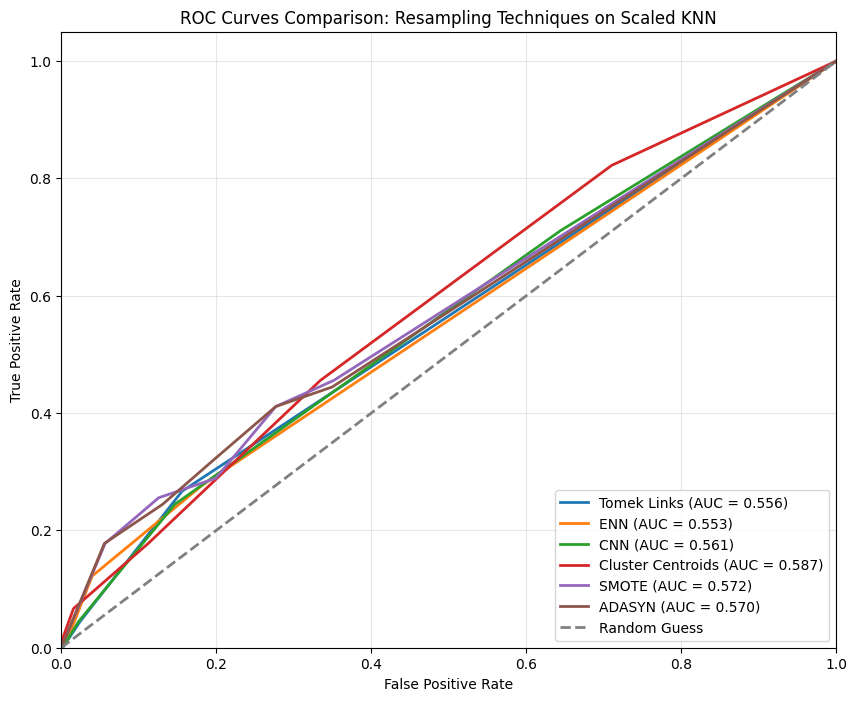

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc
from imblearn.under_sampling import TomekLinks, EditedNearestNeighbours, CondensedNearestNeighbour, ClusterCentroids
from imblearn.over_sampling import SMOTE, ADASYN

# 1. Define features and target
X = df_highly_imbalanced.drop('FGC-FGC_TL_Zone', axis=1)
y = df_highly_imbalanced['FGC-FGC_TL_Zone']

# 2. Train-test split (70/30) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. MUST DO: Feature Scaling before resampling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Define all resamplers in a single dictionary
resamplers = {
    "Tomek Links": TomekLinks(),
    "ENN": EditedNearestNeighbours(),
    "CNN": CondensedNearestNeighbour(random_state=42),
    "Cluster Centroids": ClusterCentroids(random_state=42),
    "SMOTE": SMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42)
}

# 5. Initialize the plot
plt.figure(figsize=(10, 8))

# 6. Iterate, train, and plot ROC for each algorithm
for name, sampler in resamplers.items():
    # Resample using SCALED training data
    X_train_res, y_train_res = sampler.fit_resample(X_train_scaled, y_train)
    
    # Train KNN
    knn = KNeighborsClassifier()
    knn.fit(X_train_res, y_train_res)
    
    # Get probabilities for the positive class (0.0) using SCALED test data
    pos_class_idx = list(knn.classes_).index(0.0)
    y_scores = knn.predict_proba(X_test_scaled)[:, pos_class_idx]
    
    # Calculate False Positive Rate, True Positive Rate, and Area Under Curve
    fpr, tpr, _ = roc_curve(y_test, y_scores, pos_label=0.0)
    roc_auc = auc(fpr, tpr)
    
    # Plot the curve
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# 7. Plot baseline (random guess) and formatting
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison: Resampling Techniques on Scaled KNN')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()